In [13]:
#from IPython.display import display, Latex

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.gridspec import GridSpec

## Import all needed libraries and python modules:

In [14]:
from importlib import reload
import functions_spin_p as fy
reload(fy)

import spin_thermoelectric_coefficients as th
reload(th)

<module 'spin_thermoelectric_coefficients' from '/mnt/c/Users/frnkl/Desktop/Thesis_codes_repository/tesis_model/site_dots_geyer/spin_thermoelectric_coefficients.py'>

# Transmission behaviour: Site dots Geyer Model 

Geyer model is based on a normal sites within a helical geometry, the Hamiltonian condering the helical geometry for the site coupling.

To the Geyer model is added laterally a coupled double quantum dots chain where it is possible to have spin accumulation or not. *The parameters are described for a Tigh Binding Hamiltonian in the Second Quantization. And the remainded parameters are used into the solution for the Hamiltonian using Green Keldysh Functions.* 

This model have the following parameters: the Energy Site $(\epsilon^{\sigma}_{i})$ where, by assumption, there is spin degeneration of them $(\Delta=0\Rightarrow\,\epsilon^{\sigma}_{i} = \epsilon_{i})$. Additionally, we include the coupling constant $\omega$ and the Zeeman Geometric field $\vec{B}$, the bandwith due to leads contributions in the self energies $(\gamma_{L(R)})$ is parametrized by the polarization due to spin aligment of the leads $(p_{L(R)})$. Additionally, we have the Temperature of the entire system $(T)$, the hopping of the sites $(V)$ and the angular momentum $L$. 

Under tight binding formulation using second quantization and renormalizing the Hamiltonian for the site dots, we have the following stuff for the central part:

$$
H_{cen}= \sum_{i}^{N} \vec{d_{i}}^{\dagger} \hat{\varepsilon}_{i}(E) \vec{d_{i}} + \sum_{i}^{N-1} \left( \vec{d_{i}}^{\dagger} \hat{V} \vec{d}_{i+1}+h.c. \right) + \lambda_{2} L \sum{i}^{N} \vec{d_{i}}^{\dagger} \left(\vec{\sigma} \cdot \vec{B} \right)
$$

here:

$$
\hat{V} = -t\,I_{N \times N} - i \lambda_{1} \left(\vec{\sigma}\cdot \vec{A} \right)
$$

$$
\varepsilon_{i} = \epsilon^{0}_{i} - \frac{\omega^{2}}{E-\epsilon^{1}_{i}}
$$


and, under the assumption that $\vec{A} = \left(0,0,0 \right)$, $\vec{B}=\left(0,B,B \right)$

$$
H_{cen}= \sum_{i}^{N} \vec{d_{i}}^{\dagger} \hat{\varepsilon}_{i}(E) \vec{d_{i}} + \sum_{i}^{N-1} \left( \vec{d_{i}}^{\dagger}  \left \{ -t\,I_{2 \times 2} \right \} \vec{d}_{i+1}+h.c. \right) + \lambda_{2} L \sum_{i}^{N} \vec{d_{i}}^{\dagger} \left(\hat{\sigma}_{y}\,B\,+\,\hat{\sigma}_{z}\,B \right)
$$

$$
\Rightarrow H_{cen} = 
\begin{pmatrix}

d_{1,\uparrow}^{*} & d_{1,\downarrow}^{*} & d_{2,\uparrow}^{*} & d_{2,\downarrow}^{*} 
\end{pmatrix}

\begin{pmatrix}
\varepsilon_{1} & -i\lambda_2 L B & -t & 0\\ 
-i\lambda_2 L B & \varepsilon_{1} & 0 & -t\\ 
-t & 0 & \varepsilon_{2} & -i\lambda_2 L B\\ 
0 & -t & i\lambda_2 L B & \varepsilon_{2} 
\end{pmatrix}

\begin{pmatrix}
d_{1,\uparrow}\\ 
a_{1,\downarrow}\\ 
d_{2,\uparrow}\\ 
d_{2,\downarrow}
\end{pmatrix}
$$

By assumption we set $\epsilon^{1}_{i}\neq0$ and $\omega\neq0$

In this analysis, the renormalized site energies are degenerated i.e. $\varepsilon^{\sigma}_{i}=\varepsilon_{i}$. So, we can perform analysis based on the variation of the hopping $V$, polarization $p_{L(R)}$

# Spin polarization definition:

Considering the set up where the Right Lead is NM ($p_{R}=0$), the spin polarization $SP_{1}$ is defined as:

$$
SP_{1}\,=\,\frac{T_{UP}-T_{DOWN}}{T_{UP}+T_{DOWN}}\,\cdot\,100\%
$$

where:

$T_{UP}$ is the total transmission for the case where $p_L=1$

$T_{DOWN}$ is the total transmission for the case where $p_L=-1$

# Toy Model:

**Fixed parameters**

$\epsilon^{0}_{1}\,=\,\epsilon^{0}_{2}\,=\,0\,meV$ 

$\epsilon^{1}_{1}\,=\epsilon^{1}_{2}\,=\,1\,meV$ 

$\gamma\,=\,1\,meV$

$\lambda_2 = 0.5\,meV$

$E\,=\,[-6,6]$ $meV$

$L = 0, \pm 1$

$t = 1\,meV$

$\omega=0.5\,meV$

$t\,=\,\,1\,meV$


In [4]:
#Energy axis

energy_axis = np.arange(-6, 6 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")

#Gamma i.e. width parameter
gamma = 1 #meV
print("The width is:",gamma,"meV")

#Site energies:
e_01 = 0 #meV
e_02 = 0 #meV
e_11 = 1 #meV
e_12 = 1 #meV

#Hopping parameter:
t = 1 #meV

# Helix geometric parameters:

lam_2 = 0.5 #meV

B = - 2



Energy axis is [-6.   -5.99 -5.98 ...  5.98  5.99  6.  ] meV
The width is: 1 meV


In [5]:
#Hopping parameter:

om = 0.1 #meV

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies to be renormalized are:", \
#       e_ren_1," meV and",e_ren_2," meV")

### $L=\pm 1$ and for different polarization configurations

In [6]:
# Angular momentum:

L = 1

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0,lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[-1.+0.j  0.+1.j -1.+0.j  0.+0.j]
 [-0.-1.j  1.+0.j  0.+0.j -1.+0.j]
 [-1.+0.j  0.+0.j -1.+0.j  0.+1.j]
 [ 0.+0.j -1.+0.j -0.-1.j  1.+0.j]]


In [7]:
#POLARIZATION p_L = p_R = 0
p_L = 1
p_R = 0

#Transmission axis

transmission_u_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

/mnt/c/Users/frnkl/Desktop/Thesis_codes_repository/tesis_model/site_dots_geyer/functions_spin_p.py:100: ComplexWarning: Casting complex values to real discards the imaginary part
  transmission_axis_up[i] = green_matrix(energy_array[i], gamma_parameter, H, sites, polarization_left, polarization_right)[0]
/mnt/c/Users/frnkl/Desktop/Thesis_codes_repository/tesis_model/site_dots_geyer/functions_spin_p.py:101: ComplexWarning: Casting complex values to real discards the imaginary part
  transmission_axis_down[i] = green_matrix(energy_array[i], gamma_parameter, H, sites, polarization_left, polarization_right)[1]


In [8]:
#POLARIZATION UP-UP
p_L_1 = -1
p_R_1 = 0

#Transmission axis

transmission_u_1_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


/tmp/ipykernel_458/2642236087.py:93: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.
  plt.subplots_adjust(top=0.9)


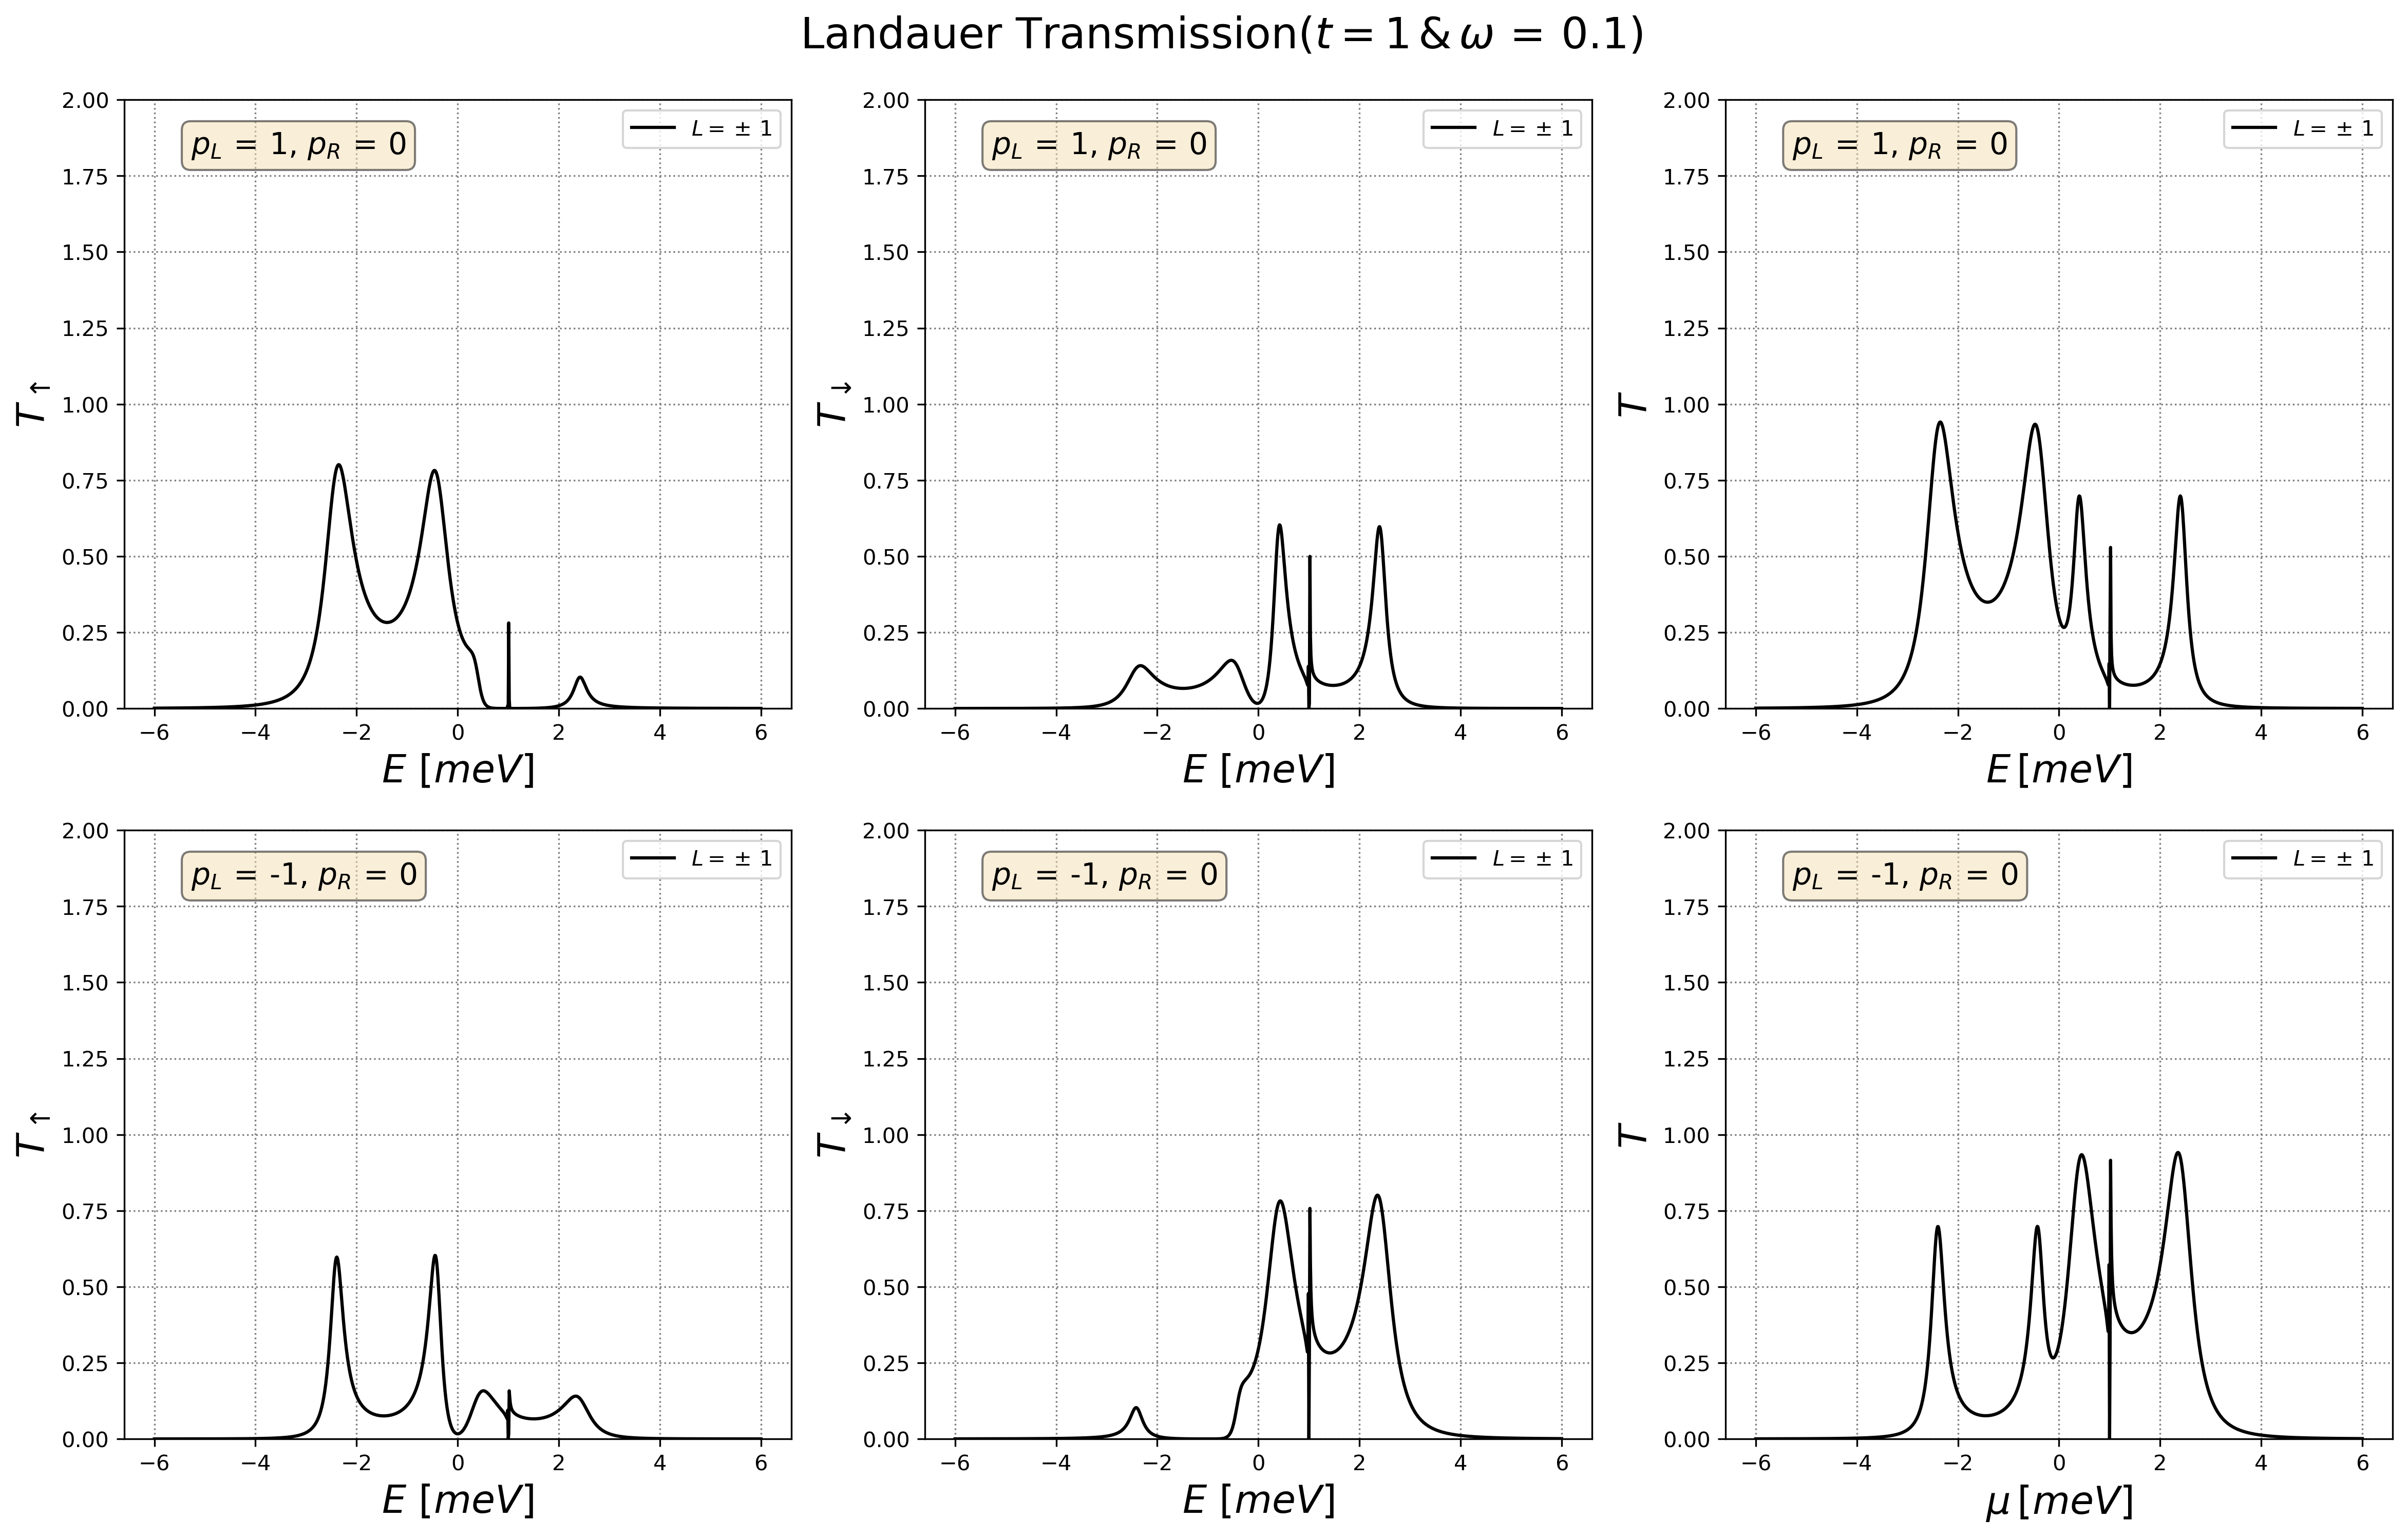

In [9]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(19, 11), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(2, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
# ax7 = fig.add_subplot(gs[2, 0])
# ax8 = fig.add_subplot(gs[2, 1])
# ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
#ax1.plot(energy_axis, transmission_u_L_0, "#1f77b4", linestyle="-", label=r"$L=0$")
ax1.plot(energy_axis, transmission_u_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
#ax2.plot(energy_axis, transmission_d_L_0, "#DC143C", linestyle="-", label=r"$L=0$")
ax2.plot(energy_axis, transmission_d_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
#ax3.plot(energy_axis, transmission_u_L_0 + transmission_d_L_0, "#8A2BE2", label = r"$L=0$")
ax3.plot(energy_axis, transmission_u_L_1 + transmission_d_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
#ax4.plot(energy_axis, transmission_u_1_L_0, "#1f77b4", linestyle="-", label=r"$L=0$")
ax4.plot(energy_axis, transmission_u_1_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
#ax5.plot(energy_axis, transmission_d_1_L_0, "#DC143C", linestyle="-", label=r"L=0")
ax5.plot(energy_axis, transmission_d_1_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
#ax6.plot(energy_axis, transmission_u_1_L_0 + transmission_d_1_L_0, "#8A2BE2", label=r"$L=0$")
ax6.plot(energy_axis, transmission_u_1_L_1 + transmission_d_1_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax6.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($t=$"+str(t)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

#fig.savefig('transmission.jpg')

In [10]:
T_UP_L_1 = transmission_u_L_1 + transmission_d_L_1
T_DOWN_L_1 = transmission_u_1_L_1 + transmission_d_1_L_1

SP1_L_1 = ( (T_UP_L_1-T_DOWN_L_1)/(T_UP_L_1+T_DOWN_L_1) )*100

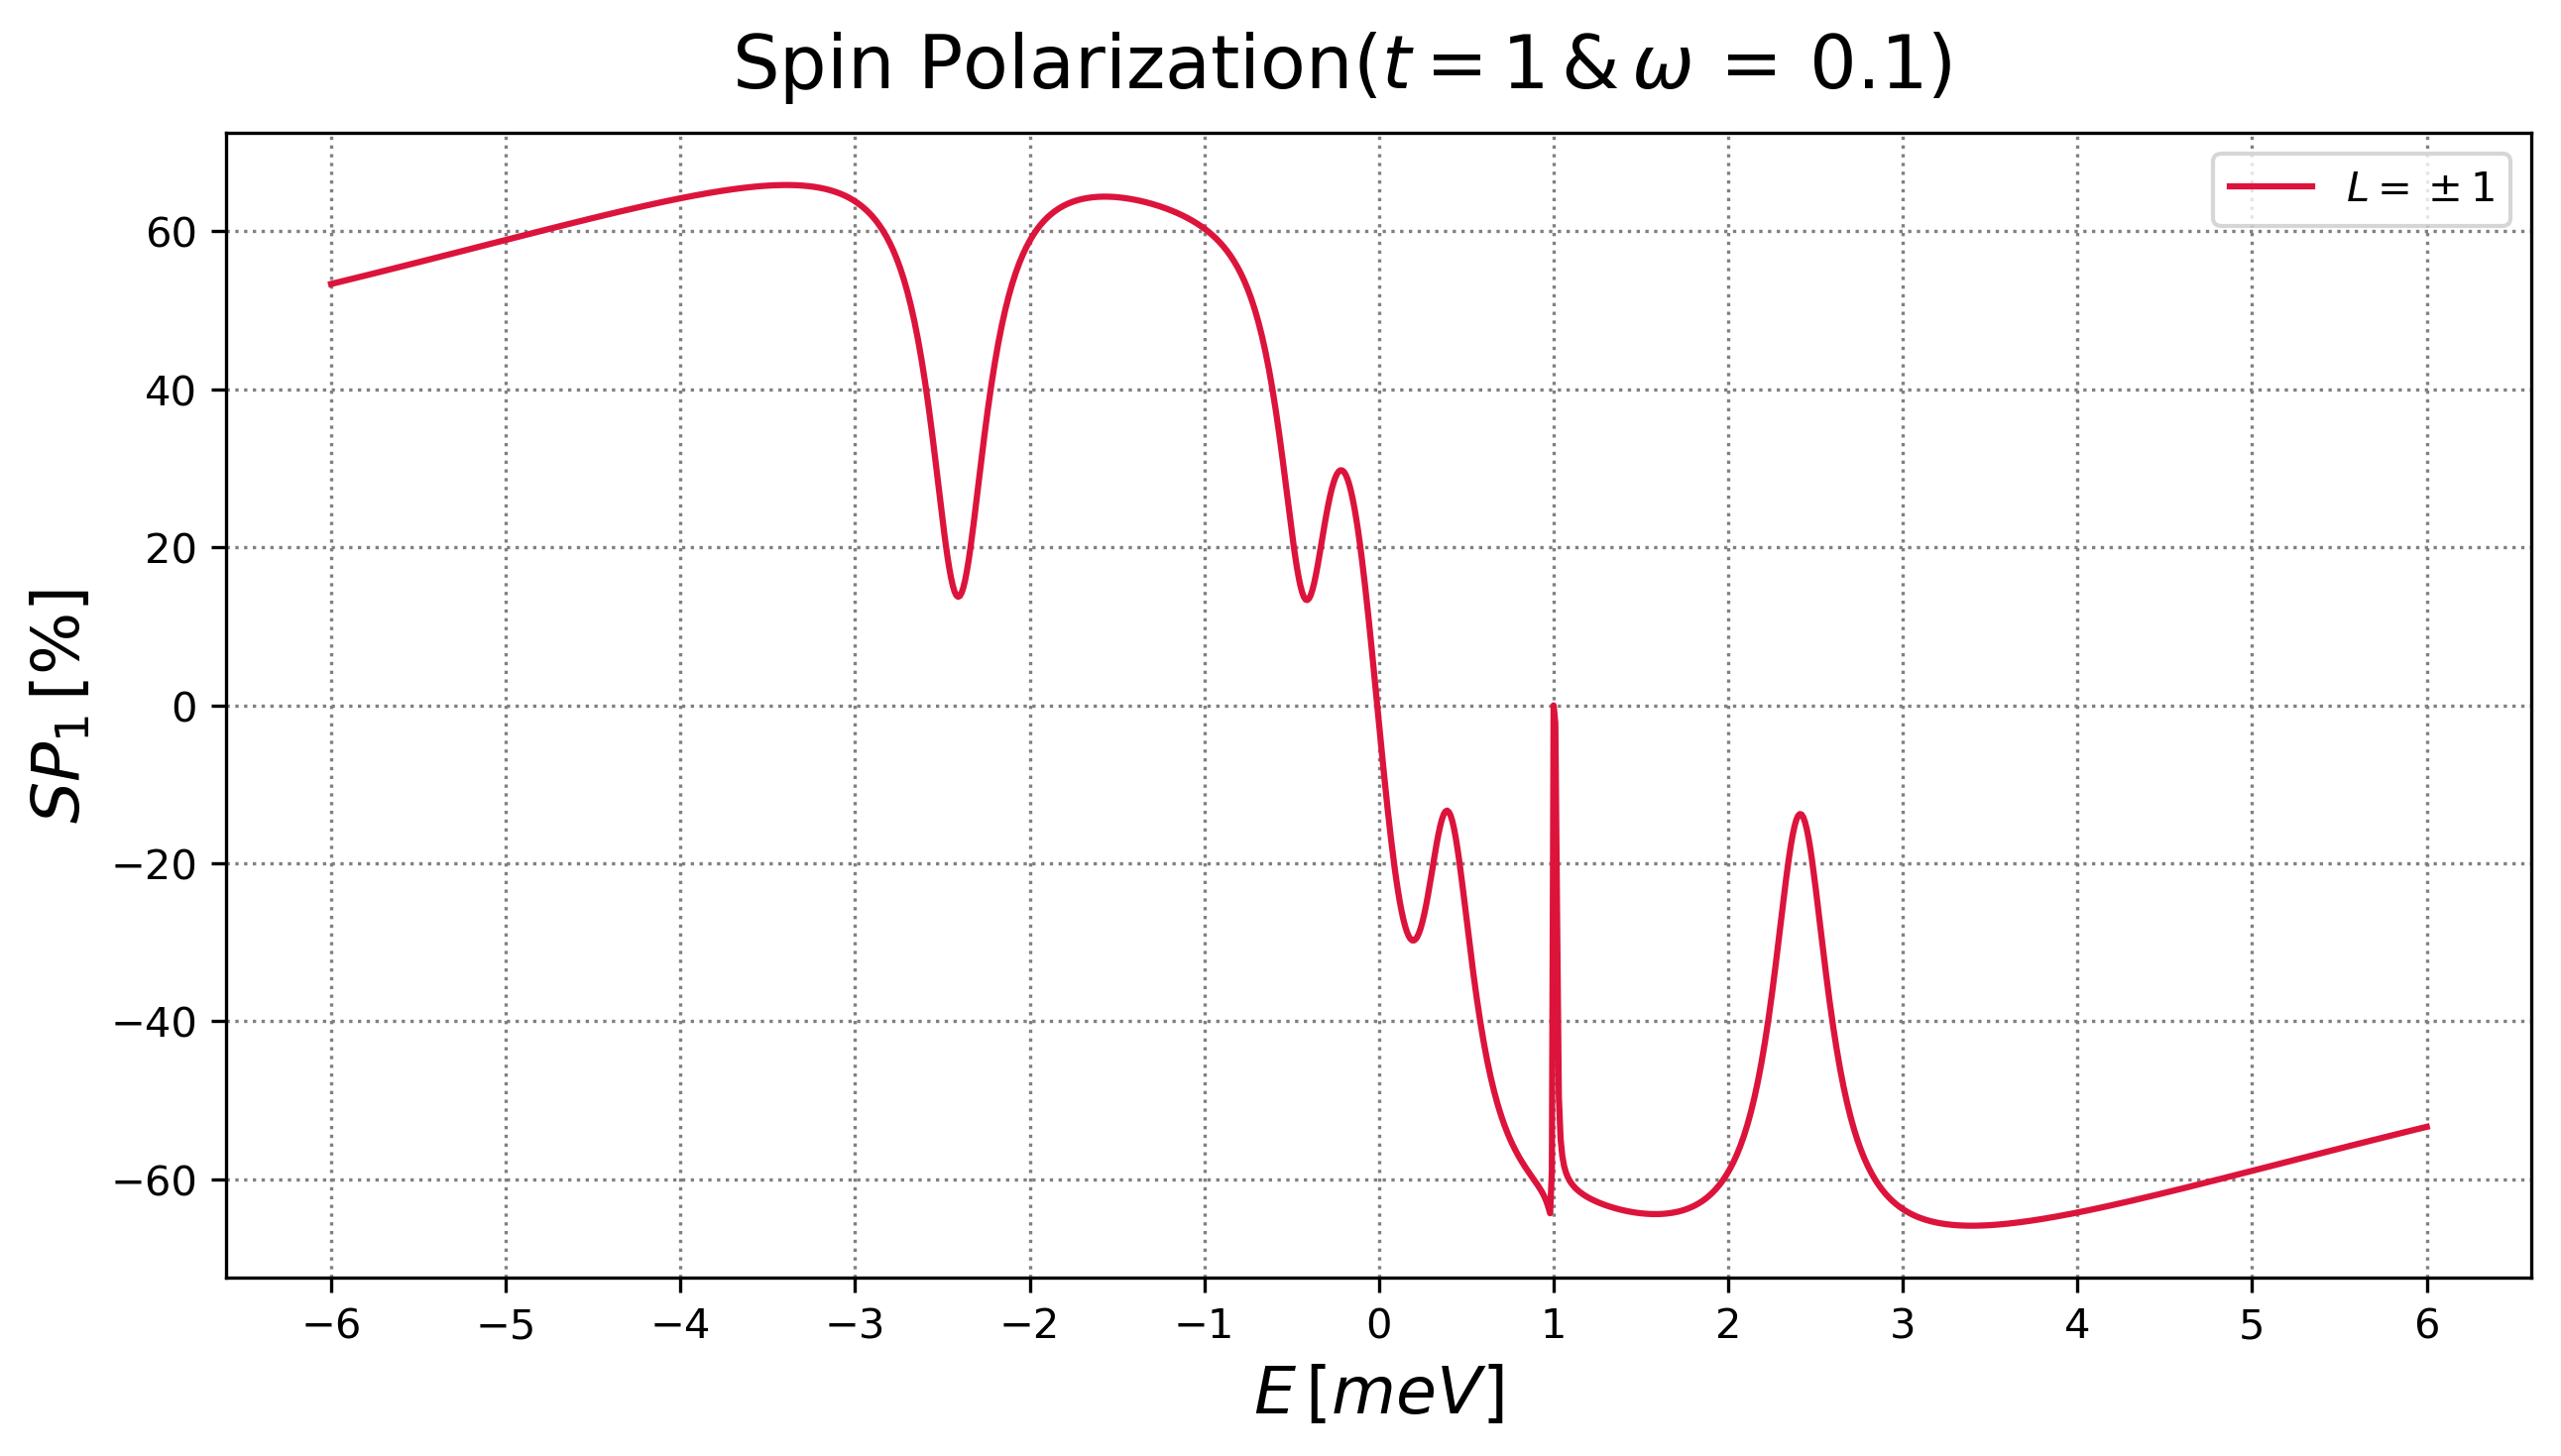

In [11]:
#Image 

plt.figure(figsize=(10, 5), dpi=300)
plt.grid(linestyle=':', color='grey')
plt.plot(energy_axis,SP1_L_1, color="#DC143C", label=r"$L=\pm 1$")
#plt.plot(energy_axis,SP1_L_0, color = "#000000", linestyle = "-.", label = r"$L=0$")
plt.xlabel(r"$E\,[meV]}$", fontsize=16)
plt.ylabel(r"$SP_{1}\,[\%]$", fontsize=16)
plt.legend( loc='upper right')

# Define the limits for the x axis
x_min = min(energy_axis)
x_max = max(energy_axis)

# Establecer los ticks del eje x
plt.xticks(range(int(x_min), int(x_max) + 2, 1))

plt.suptitle("Spin Polarization"+r"($t=$"+str(t)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=18, y=0.95)
#plt.savefig('spin_polarization.jpg')
plt.show()

# Join both images (Transmission and Spin Polarization) in only one image

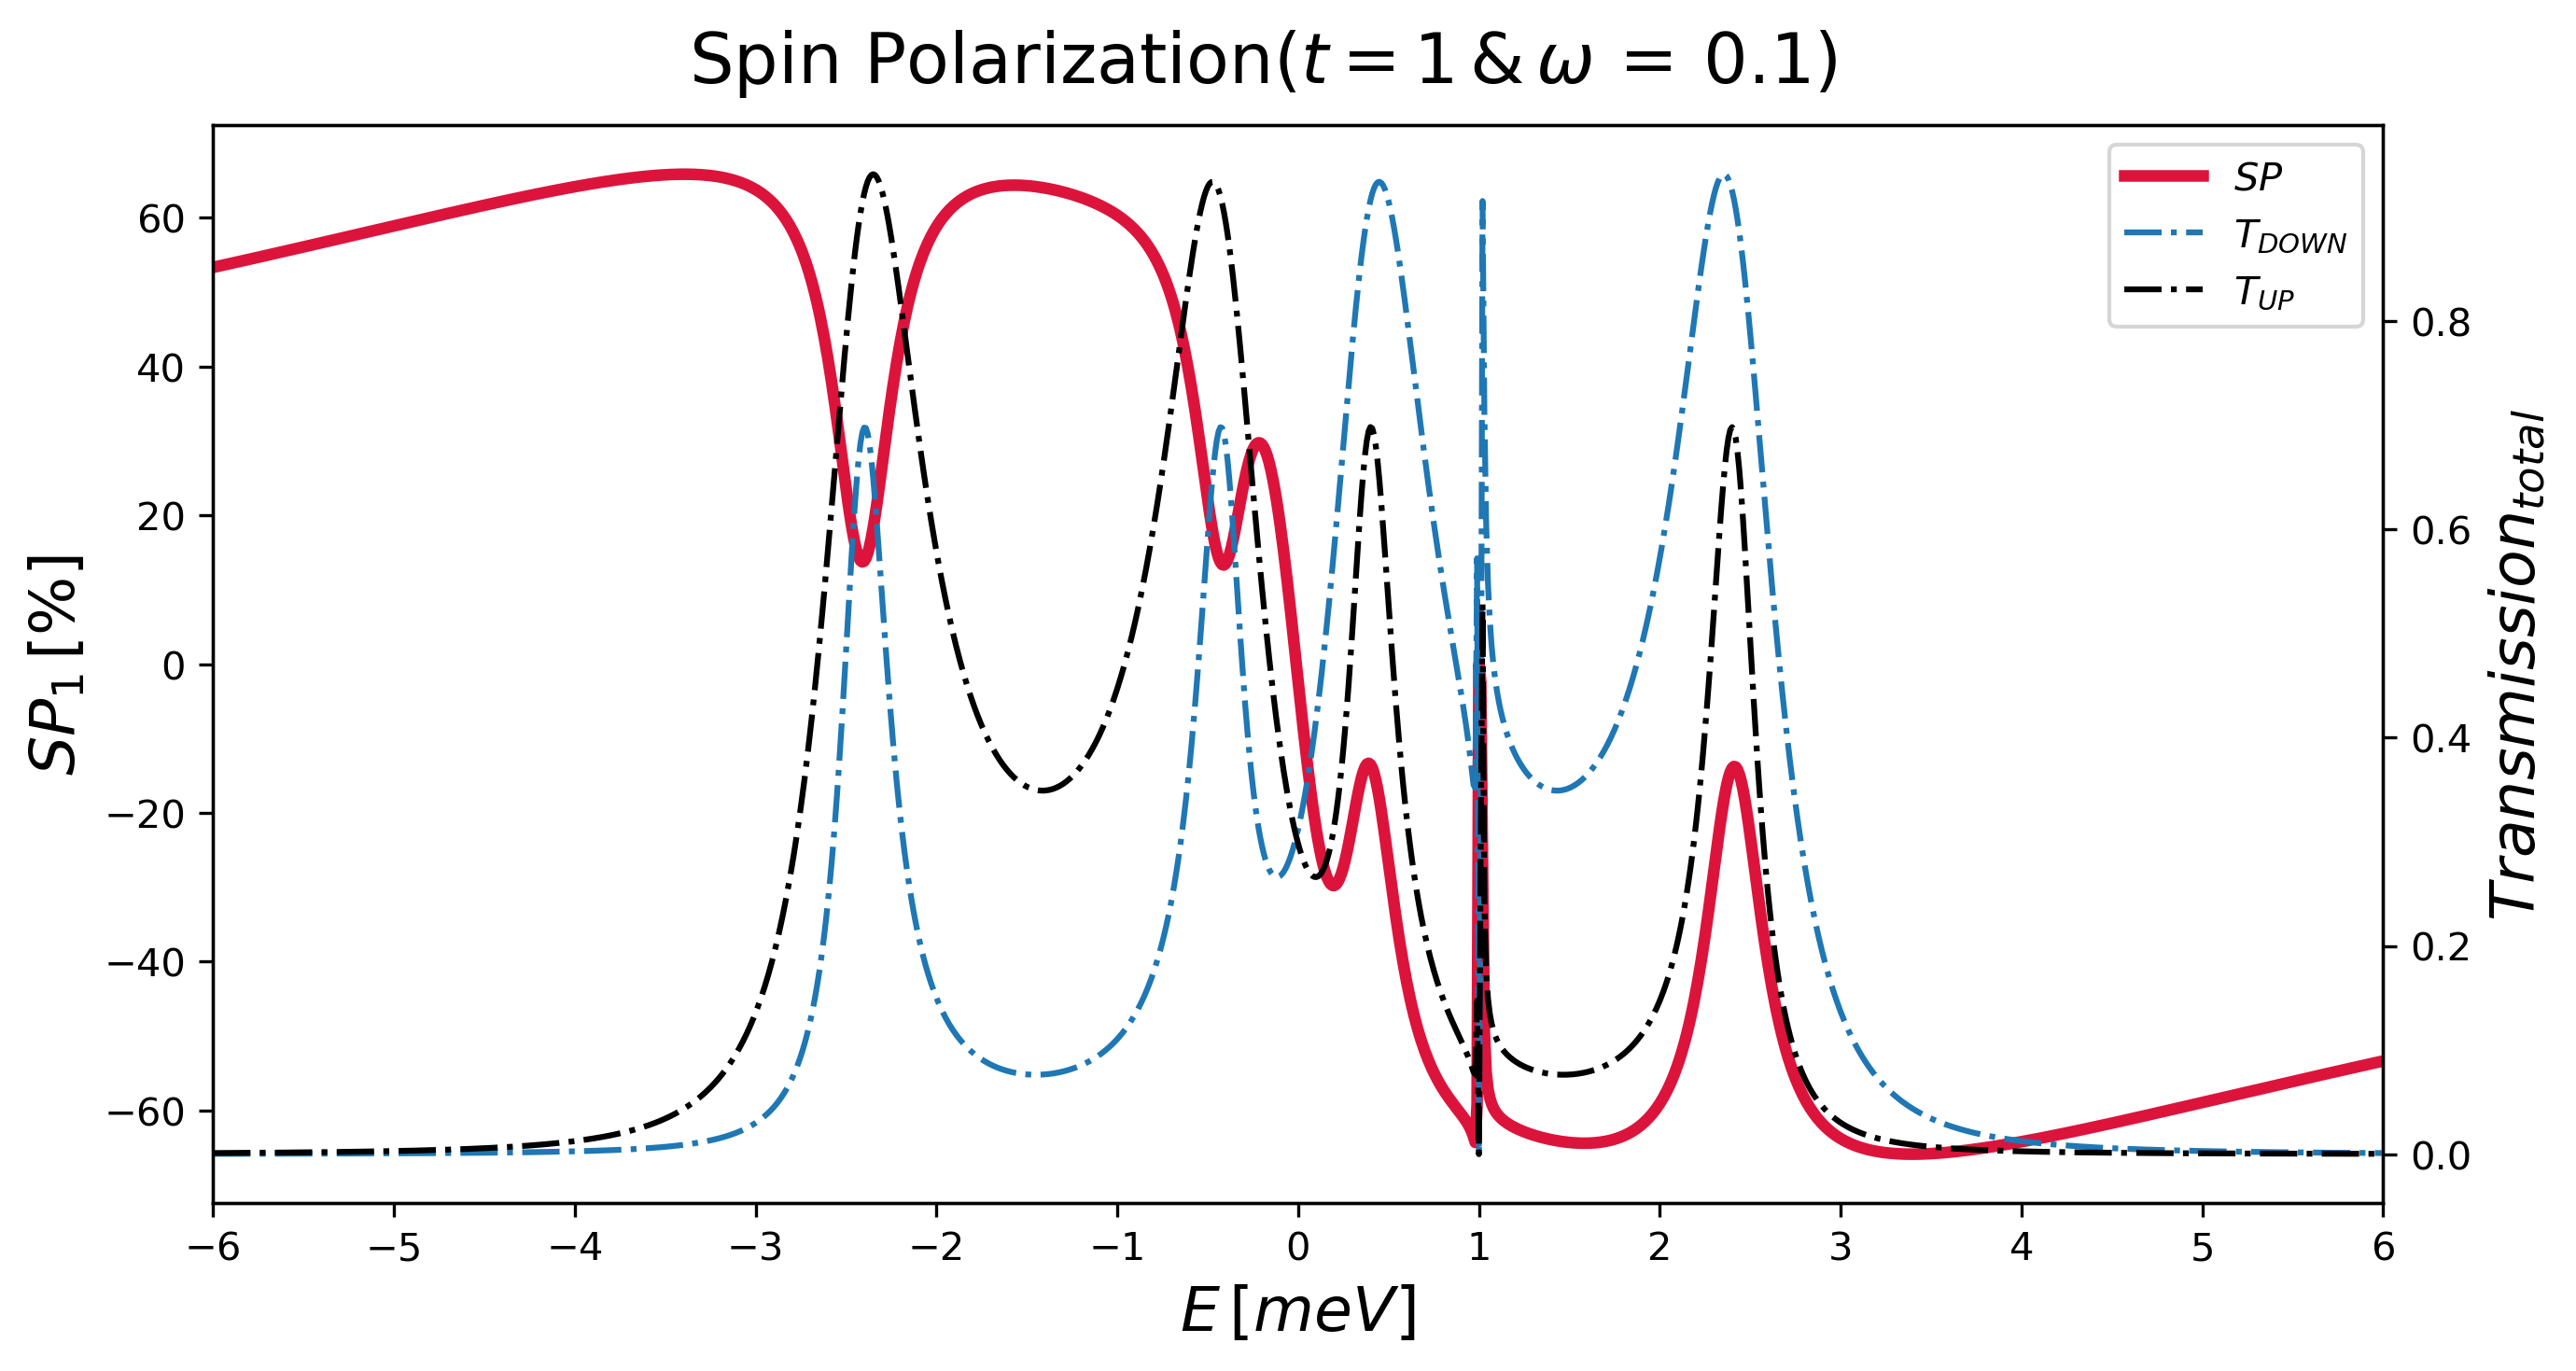

In [12]:
# Crear la figura y los ejes
fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

# Define the first axis and its y-scale (linear scale)
ax1.plot(energy_axis, SP1_L_1, color="#DC143C", label=r"$SP$", lw=3)
ax1.set_xlabel(r"$E\,[meV]$", fontsize=16)
ax1.set_ylabel(r"$SP_{1}\,[\%]$", fontsize=16)

# Make the second y axis (logarítmic scale)
ax2 = ax1.twinx()
ax2.plot(energy_axis, transmission_u_1_L_1 + transmission_d_1_L_1, "#1f77b4", linestyle="-.", label=r"$T_{DOWN}$")
ax2.plot(energy_axis, transmission_u_L_1 + transmission_d_L_1, "#000000", linestyle="-.", label=r"$T_{UP}$")
#ax2.plot(energy_axis, T_UP_L_1-T_DOWN_L_1, "#000000", linestyle="-.", label=r"$T_{UP}$")

ax2.set_ylabel(r"$Transmission_{total}$", fontsize=16)


# Obtain legends and lines for both axis
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Locate the legends such that it is not superposted
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Adjust the x axis ticks 
x_min = min(energy_axis)
x_max = max(energy_axis)
ax1.set_xlim(x_min, x_max)

# Stablish the x axis ticks in intervals of 1
ax1.set_xticks(range(int(x_min), int(x_max) + 2, 1)) 

# Headline
plt.suptitle("Spin Polarization" + r"($t=$" + str(t) + r"$\,&\,\omega\,=\,$" + str(om) + ")", fontsize=18, y=0.95)

# Show the image
plt.show()

#Save the image
#fig.savefig('Spin_Polarization_final.jpg')


In [125]:
#Energy axis

energy_axis = np.arange(0.8, 1.2 + 0.01, 0.01) #meV
print("Energy axis is", energy_axis,"meV")


Energy axis is [0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93
 0.94 0.95 0.96 0.97 0.98 0.99 1.   1.01 1.02 1.03 1.04 1.05 1.06 1.07
 1.08 1.09 1.1  1.11 1.12 1.13 1.14 1.15 1.16 1.17 1.18 1.19 1.2 ] meV


In [126]:
#Hopping parameter:

om = 0.1 #meV

#Renormalized site energies array:
e_ren_1 = np.array([e_01,e_11, om])

e_ren_2 = np.array([e_02, e_12, om])

# print("The site (spin independent) energies to be renormalized are:", \
#       e_ren_1," meV and",e_ren_2," meV")

### $L=\pm 1$ and for different polarization configurations

In [127]:
# Angular momentum:

L = 1

e_ren_1_u = e_ren_1  #meV
e_ren_1_d = e_ren_1  #meV
e_ren_2_u = e_ren_2  #meV
e_ren_2_d = e_ren_2  #meV

site_energies = np.array([e_ren_1_u, e_ren_1_d , e_ren_2_u , e_ren_2_d], dtype = complex)
#print(site_energies)

Hamiltonian = np.array([[lam_2*L*B, -(1j)*lam_2*L*B,-t,0],[(1j)*lam_2*L*B, -lam_2*L*B, 0,-t],[-t,0,lam_2*L*B, -(1j)*lam_2*L*B],\
                        [0,-t, (1j)*lam_2*L*B, -lam_2*L*B]], dtype = complex)

print(Hamiltonian)

[[-1.+0.j  0.+1.j -1.+0.j  0.+0.j]
 [-0.-1.j  1.+0.j  0.+0.j -1.+0.j]
 [-1.+0.j  0.+0.j -1.+0.j  0.+1.j]
 [ 0.+0.j -1.+0.j -0.-1.j  1.+0.j]]


In [128]:
#POLARIZATION p_L = p_R = 0
p_L = 1
p_R = 0

#Transmission axis

transmission_u_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[0]
transmission_d_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L, p_R)[1]

In [129]:
#POLARIZATION UP-UP
p_L_1 = -1
p_R_1 = 0

#Transmission axis

transmission_u_1_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[0]
transmission_d_1_L_1 = fy.Transmission(energy_axis, gamma, Hamiltonian, site_energies, p_L_1, p_R_1)[1]


/home/franklin/miniconda3/envs/py37/lib/python3.7/site-packages/ipykernel_launcher.py:93: UserWarning: This figure was using constrained_layout, but that is incompatible with subplots_adjust and/or tight_layout; disabling constrained_layout.


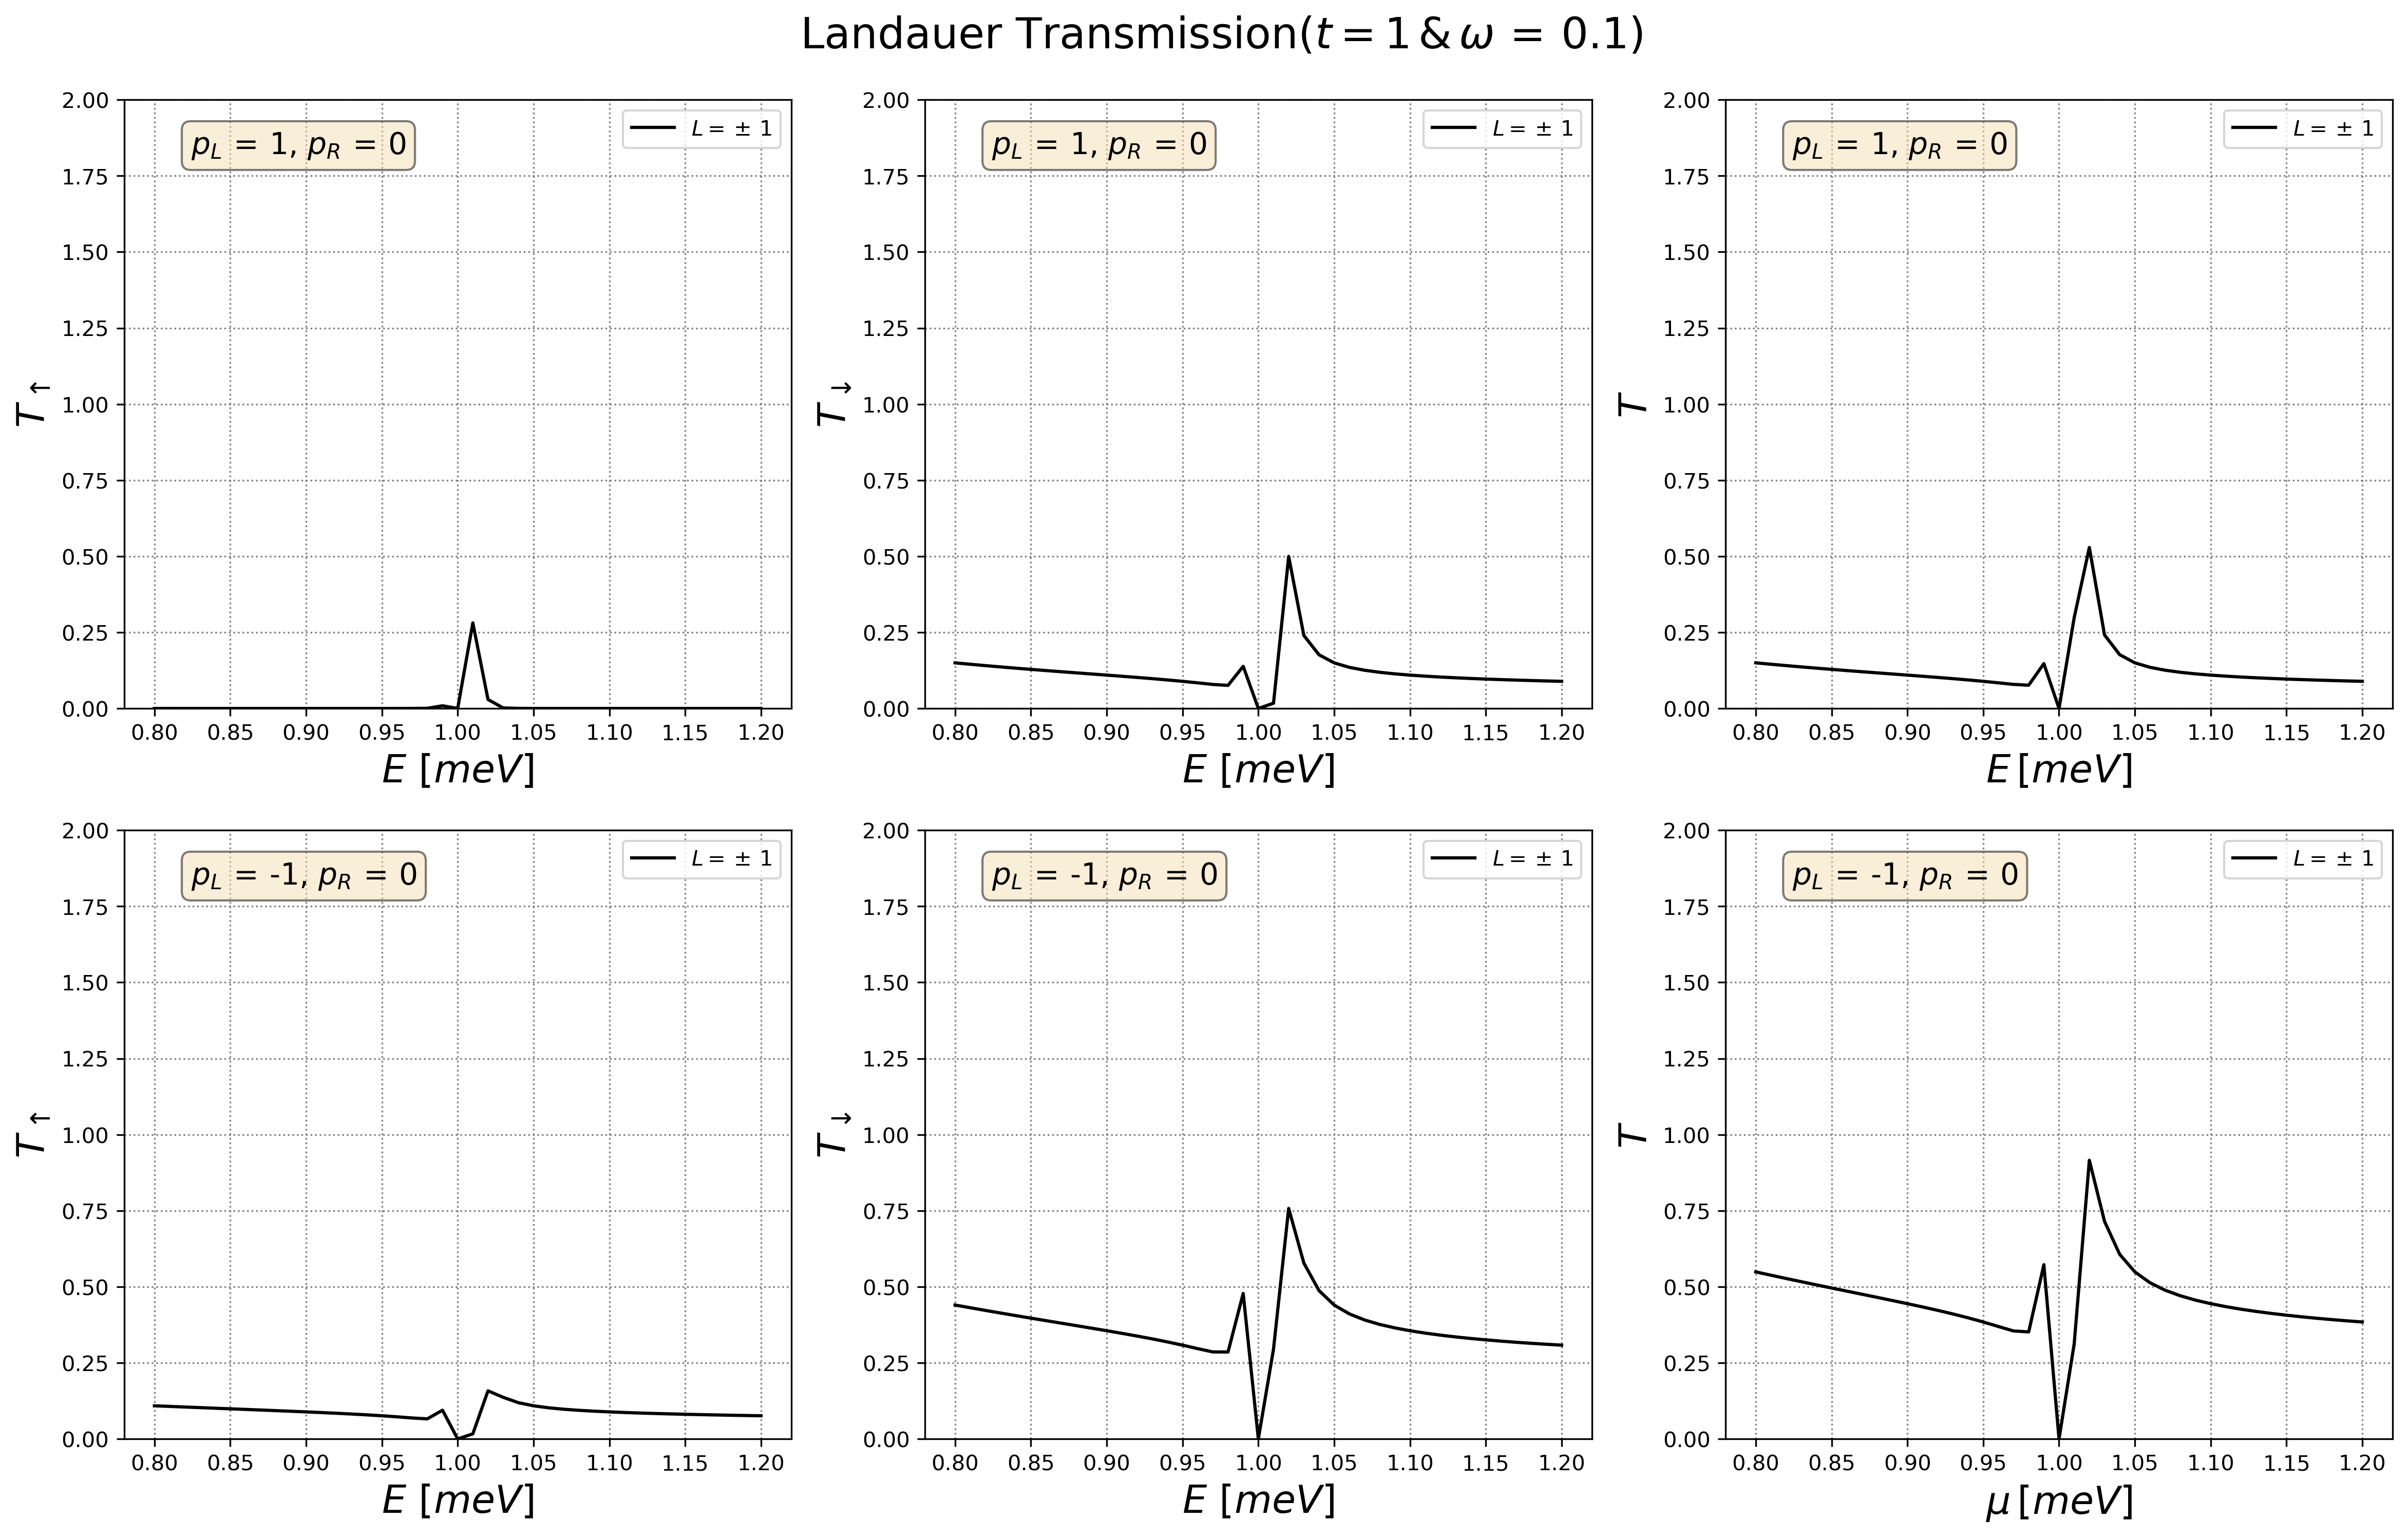

In [130]:
# do not forget constrained_layout=True to have some space between axes
fig = plt.figure(constrained_layout=True, figsize=(19, 11), dpi=300)

# these are matplotlib.patch.Patch properties
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

#Set the grid for the subplots
gs = GridSpec(2, 3, figure=fig)

#Add the subplots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])
# ax7 = fig.add_subplot(gs[2, 0])
# ax8 = fig.add_subplot(gs[2, 1])
# ax9 = fig.add_subplot(gs[2, 2])

# 0 - 0
# Transmission UP Plot
ax1.grid(linestyle=':', color='grey')
#ax1.plot(energy_axis, transmission_u_L_0, "#1f77b4", linestyle="-", label=r"$L=0$")
ax1.plot(energy_axis, transmission_u_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax1.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax1.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax1.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax1.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax1.legend( loc='upper right')

# Transmission DOWN Plot
ax2.grid(linestyle=':', color='grey')
#ax2.plot(energy_axis, transmission_d_L_0, "#DC143C", linestyle="-", label=r"$L=0$")
ax2.plot(energy_axis, transmission_d_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax2.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax2.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax2.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax2.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax2.legend( loc='upper right')

# Total Transmission Plot
ax3.grid(linestyle=':', color='grey')
#ax3.plot(energy_axis, transmission_u_L_0 + transmission_d_L_0, "#8A2BE2", label = r"$L=0$")
ax3.plot(energy_axis, transmission_u_L_1 + transmission_d_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax3.set_xlabel(r'$E\,[meV]$',fontsize=18)
ax3.set_ylabel(r"$T$",fontsize=18)
ax3.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L)+", "r"$p_{R}\,=\,$"+str(p_R), transform=ax3.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax3.legend( loc='upper right')  

# UP - UP

ax4.grid(linestyle=':', color='grey')
#ax4.plot(energy_axis, transmission_u_1_L_0, "#1f77b4", linestyle="-", label=r"$L=0$")
ax4.plot(energy_axis, transmission_u_1_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax4.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax4.set_ylabel(r'$T_{\uparrow}$',fontsize=18)
ax4.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax4.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax4.legend( loc='upper right')

ax5.grid(linestyle=':', color='grey')
#ax5.plot(energy_axis, transmission_d_1_L_0, "#DC143C", linestyle="-", label=r"L=0")
ax5.plot(energy_axis, transmission_d_1_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax5.set_xlabel(r'$E\,\,[meV]$',fontsize=18)
ax5.set_ylabel(r'$T_{\downarrow}$',fontsize=18)
ax5.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax5.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax5.legend( loc='upper right')

ax6.grid(linestyle=':', color='grey')
#ax6.plot(energy_axis, transmission_u_1_L_0 + transmission_d_1_L_0, "#8A2BE2", label=r"$L=0$")
ax6.plot(energy_axis, transmission_u_1_L_1 + transmission_d_1_L_1, "#000000", linestyle="-", label=r"$L=\pm\,1$")
ax6.set_xlabel(r'$\mu\,[meV]$',fontsize=18)
ax6.set_ylabel(r"$T$",fontsize=18)
ax6.text(0.1, 0.95, r"$p_{L}\,=\,$"+str(p_L_1)+", "r"$p_{R}\,=\,$"+str(p_R_1), transform=ax6.transAxes, fontsize=14,
        verticalalignment='top', bbox=props)
ax6.legend( loc='upper right')

# Stablish limits for the subplots
ax1.set_ylim(0, 2)  
ax2.set_ylim(0, 2)   
ax3.set_ylim(0, 2)  
ax4.set_ylim(0, 2)  
ax5.set_ylim(0, 2)   
ax6.set_ylim(0, 2)  

# Ajustar el diseño y mostrar los subplots
plt.suptitle("Landauer Transmission"+r"($t=$"+str(t)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=20, y=0.95)

# Ajustar el espacio superior
plt.subplots_adjust(top=0.9)

#plt.tight_layout()

plt.show()

#fig.savefig('transmission.jpg')

In [131]:
T_UP_L_1 = transmission_u_L_1 + transmission_d_L_1
T_DOWN_L_1 = transmission_u_1_L_1 + transmission_d_1_L_1

SP1_L_1 = ( (T_UP_L_1-T_DOWN_L_1)/(T_UP_L_1+T_DOWN_L_1) )*100

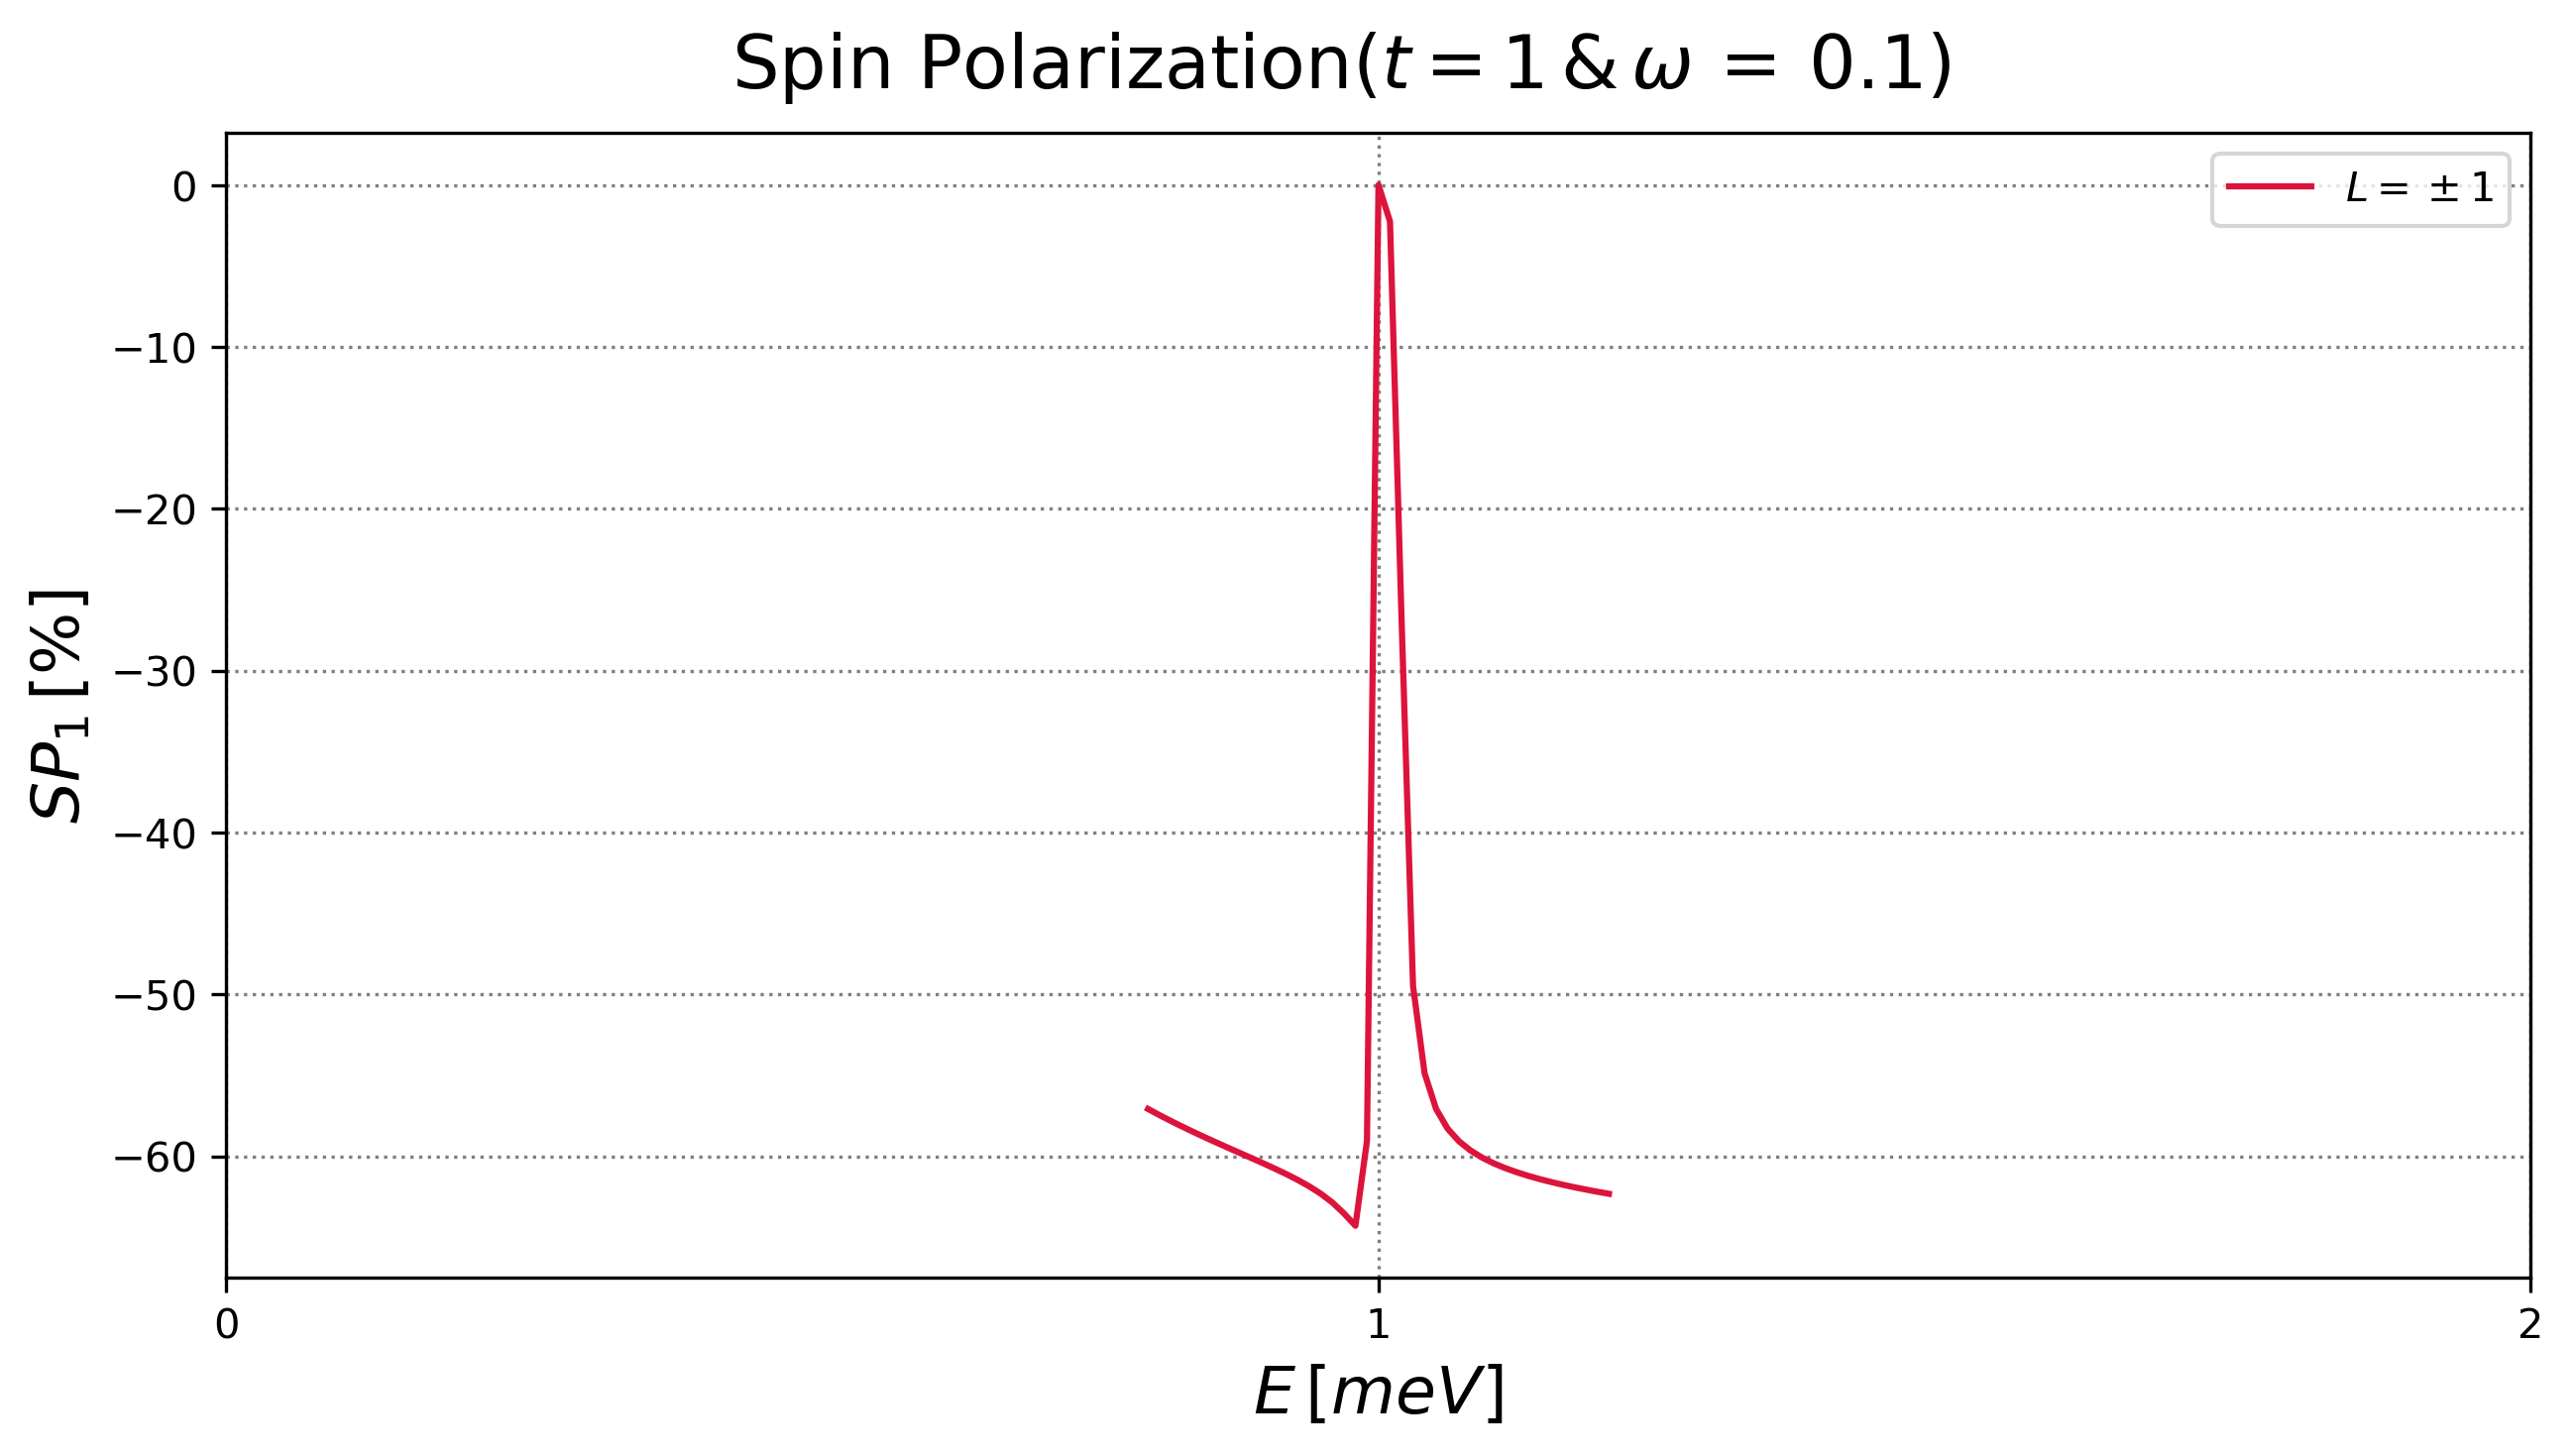

In [132]:
#Image 

plt.figure(figsize=(10, 5), dpi=300)
plt.grid(linestyle=':', color='grey')
plt.plot(energy_axis,SP1_L_1, color="#DC143C", label=r"$L=\pm 1$")
#plt.plot(energy_axis,SP1_L_0, color = "#000000", linestyle = "-.", label = r"$L=0$")
plt.xlabel(r"$E\,[meV]}$", fontsize=16)
plt.ylabel(r"$SP_{1}\,[\%]$", fontsize=16)
plt.legend( loc='upper right')

# Define the limits for the x axis
x_min = min(energy_axis)
x_max = max(energy_axis)

# Establecer los ticks del eje x
plt.xticks(range(int(x_min), int(x_max) + 2, 1))

plt.suptitle("Spin Polarization"+r"($t=$"+str(t)+r"$\,&\,\omega\,=\,$"+str(om)+")", fontsize=18, y=0.95)
#plt.savefig('spin_polarization.jpg')
plt.show()

# Join both images (Transmission and Spin Polarization) in only one image

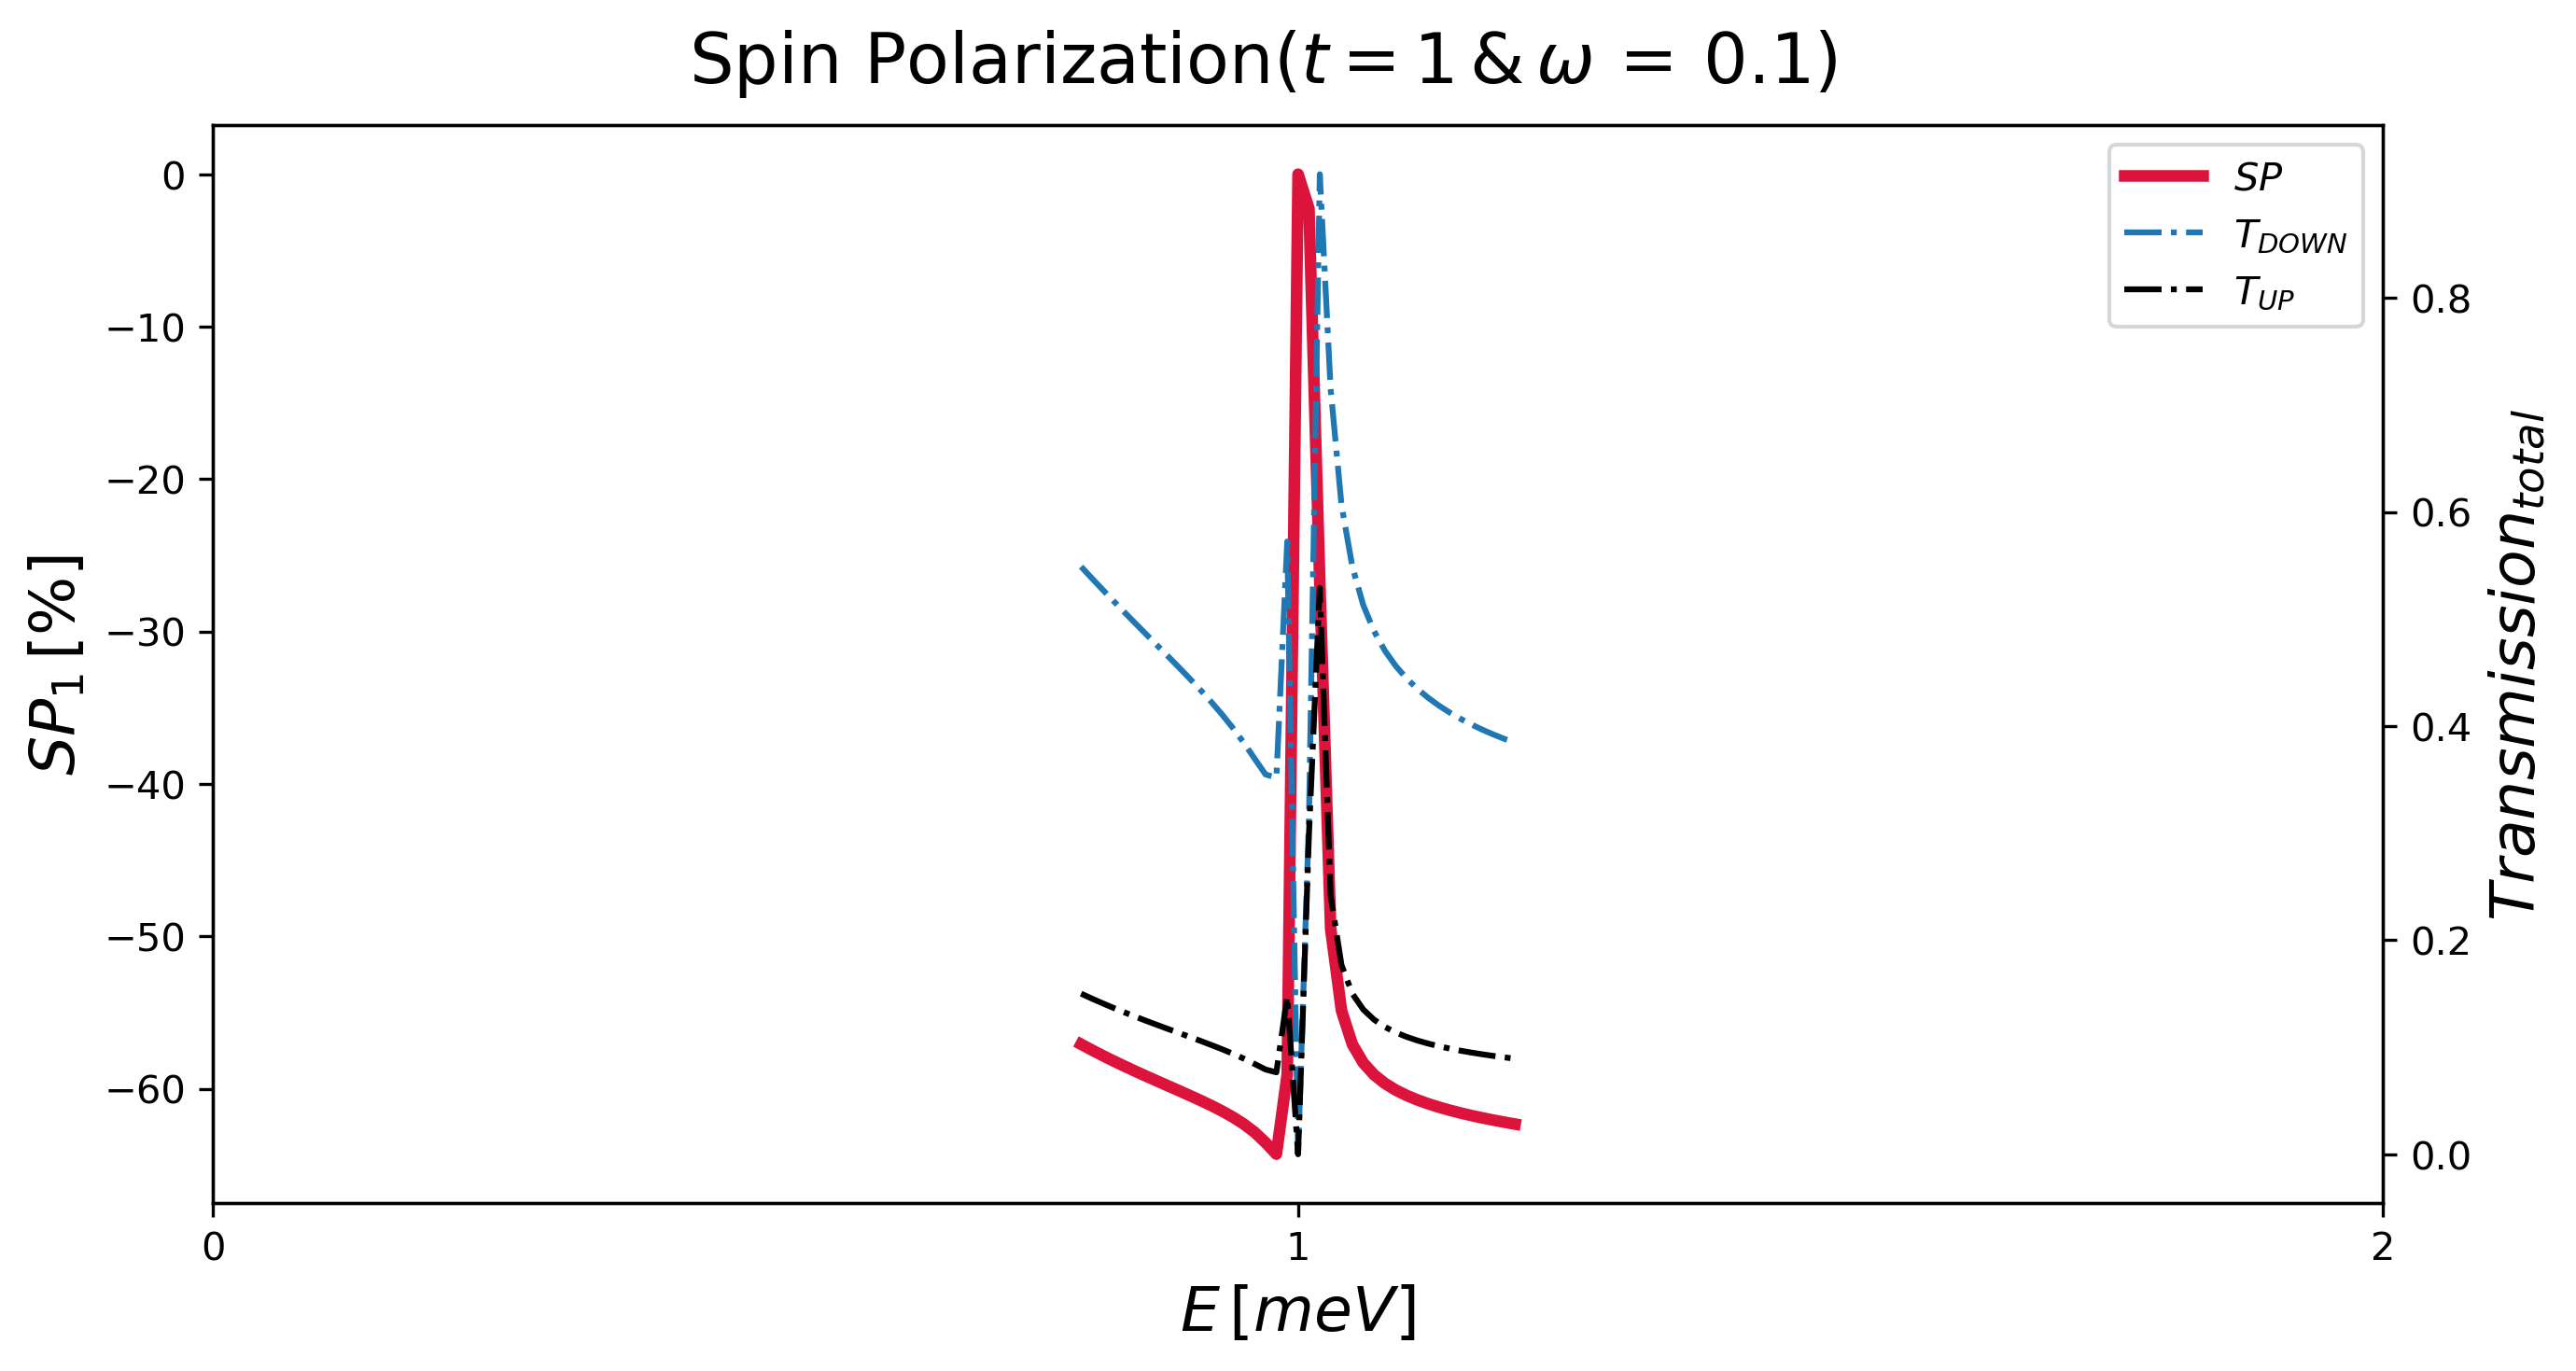

In [133]:
# Crear la figura y los ejes
fig, ax1 = plt.subplots(figsize=(10, 5), dpi=300)

# Define the first axis and its y-scale (linear scale)
ax1.plot(energy_axis, SP1_L_1, color="#DC143C", label=r"$SP$", lw=3)
ax1.set_xlabel(r"$E\,[meV]$", fontsize=16)
ax1.set_ylabel(r"$SP_{1}\,[\%]$", fontsize=16)

# Make the second y axis (logarítmic scale)
ax2 = ax1.twinx()
ax2.plot(energy_axis, transmission_u_1_L_1 + transmission_d_1_L_1, "#1f77b4", linestyle="-.", label=r"$T_{DOWN}$")
ax2.plot(energy_axis, transmission_u_L_1 + transmission_d_L_1, "#000000", linestyle="-.", label=r"$T_{UP}$")
#ax2.plot(energy_axis, T_UP_L_1-T_DOWN_L_1, "#000000", linestyle="-.", label=r"$T_{UP}$")

ax2.set_ylabel(r"$Transmission_{total}$", fontsize=16)


# Obtain legends and lines for both axis
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Locate the legends such that it is not superposted
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# Adjust the x axis ticks 
x_min = min(energy_axis)
x_max = max(energy_axis)
ax1.set_xlim(x_min, x_max)

# Stablish the x axis ticks in intervals of 1
ax1.set_xticks(range(int(x_min), int(x_max) + 2, 1)) 

# Headline
plt.suptitle("Spin Polarization" + r"($t=$" + str(t) + r"$\,&\,\omega\,=\,$" + str(om) + ")", fontsize=18, y=0.95)

# Show the image
plt.show()

#Save the image
#fig.savefig('Spin_Polarization_final.jpg')
